## Interpolazione polinomiale

**Implementazione del metodo dei coefficienti indeterminati**

Date le coppie di punti $(x_i,y_i)$, $i=0,...,n$, si vuole determinare l'unico polinomio di grado $n$ al cui grafico appartengono i punti dati.

Formula di un polinomio di grado $n$ in forma canonica:
$$p_n(x) = a_1+a_1x + a_2x^2+...+a_nx^n $$
Condizioni di interpolazione:
$$p_n(x_i) = y_i, \ \ i=0,...,n$$

Mettendo insieme le due formule si ottengono le seguenti uguaglianze

$$
\left\{
\begin{array}{lcl}
a_0 + a_1x_0 + a_2x_0^2+...+a_nx_0^n &=& y_0\\
a_0 + a_1x_1 + a_2x_1^2+...+a_nx_1^n &=& y_1\\
 & \vdots\\
a_0 + a_1x_n + a_2x_n^2+...+a_nx_n^n &=& y_n\\
\end{array}
\right.
$$
che vanno interpretate come un sistema lineare di $n+1$ equazioni nelle $n+1$ incognite $a_0,a_1,a_2,...,a_n$.

La forma matriciale del sistema è la seguente
$$ V\alpha = y$$
dove
$$V= \left(\begin{array}{cccc}
1 & x_0 & {x_0}^2  & \dots  & {x_0}^n \\
1 & x_1 & {x_1}^2  & \dots  & {x_1}^n \\
\vdots  & \vdots & \vdots &  & \vdots \\
1&x_n   & {x_n}^2  & \dots  & {x_n}^n
\end{array}\right), \qquad \alpha = \begin{pmatrix}a_0\\a_1\\ \vdots\\a_n\end{pmatrix},\ y = \begin{pmatrix}y_0\\y_1\\ \vdots\\y_n\end{pmatrix}$$

Il coefficienti dell'unico polinomio di interpolazione si ottengono quindi risolvendo il sistema qui sopra.



In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
def pol_interp(x,y):
  n = x.size
  V = np.ones((n,n))
  for i in range(1,n):    # La colonna successiva è la colonna 
    V[:,i] = V[:,i-1]*x   # precedente moltiplicata per x.
  return np.linalg.solve(V,y)

### Esempio

Creiamo il grafico del polinomio di interpolazione rispetto ai punti dati nell'esempio seguente

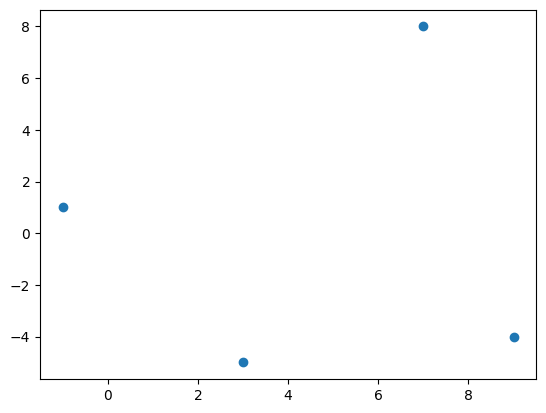

In [11]:
x = np.array([-1,3,7,9])
y = np.array([1,-5,8,-4])

plt.scatter(x,y)
plt.show()

[-6.765625   -5.03645833  2.515625   -0.21354167]


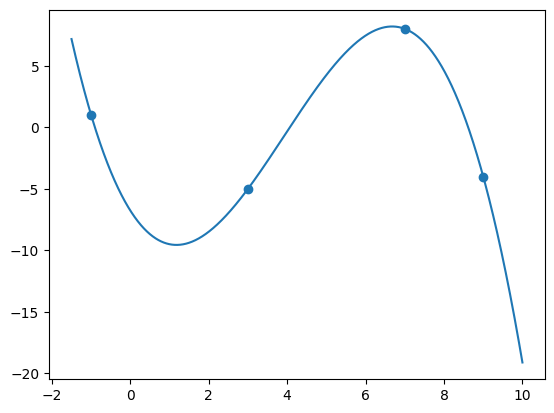

In [12]:
plt.scatter(x,y)
a = pol_interp(x,y)
print(a)

xx = np.linspace(-1.5,10,num=2000)
yy = np.polyval(a[-1::-1],xx)
plt.plot(xx,yy)
plt.show()

La funzione di Numpy che calcola il polinomio di interpolazione è `polyfit`, se usata nel modo seguente (si veda [qui](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) per la descrizione completa)

[-0.21354167  2.515625   -5.03645833 -6.765625  ]


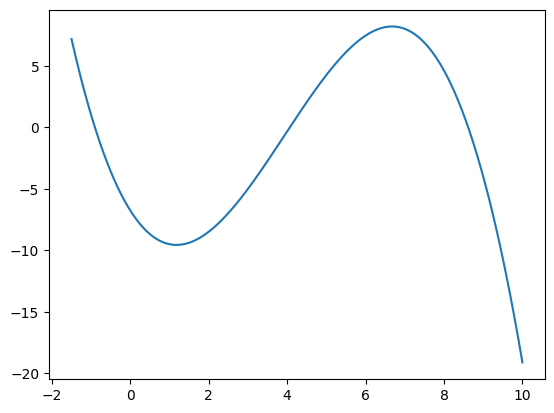

In [13]:
b = np.polyfit(x,y,x.size-1)
print(b)

zz = np.polyval(b,xx)
plt.plot(xx,zz)
plt.show()
